# SRTM 30 m DEM Terrain & Hydrology Analysis

A reproducible Python workflow for downloading **SRTM 1 arc-second elevation data**, clipping it to a user-defined area of interest (AOI), projecting the DEM to a local **30 m UTM grid**, and deriving terrain and hydrologic products.

The notebook supports two AOI workflows: a vector file (Shapefile, GeoPackage, GeoJSON, or ZIP) or an interactive map. It then performs a complete processing chain from raw SRTM tiles to terrain derivatives, D8 flow routing, drainage area, topographic wetness, and vector stream extraction.

### Main outputs

- Clipped and projected DEMs
- Filled and hydrologically conditioned DEMs
- Sink depth and sink mask
- Slope (degrees and percent), aspect, and hillshade
- Laplacian curvature, TPI, TRI, and roughness
- D8 flow direction and flow accumulation
- Drainage area and Topographic Wetness Index (TWI)
- Stream raster and stream-network Shapefiles in UTM and WGS84

> **Data source:** NASA SRTM 1 arc-second tiles distributed through the AWS `elevation-tiles-prod/skadi` archive.

In [1]:
%pip install -q "rasterio>=1.4" geopandas shapely pyproj requests tqdm ipyleaflet ipywidgets matplotlib scipy pysheds
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    pass

## 1. Configuration

Set the analysis mode, input/output locations, and processing parameters before running the workflow.

| Parameter | Purpose | Default |
|---|---|---:|
| `MODE` | AOI source: `"shapefile"` or `"map"` | `"shapefile"` |
| `SHAPEFILE_PATH` | Optional vector AOI path; if blank, the notebook prompts for it | `""` |
| `OUTPUT_DIR` | Root folder for downloaded tiles and generated products | `./outputs` |
| `TARGET_RESOLUTION` | Output DEM resolution in meters | `30` |
| `STREAM_THRESHOLD_KM2` | Minimum contributing area used to define streams | `2.0` |
| `TPI_WINDOW` | Moving-window size used for TPI | `9` |
| `MAX_TILES` | Safety limit for the number of SRTM tiles | `500` |

The notebook creates `tiles/` for cached SRTM files and `dem_products/` for derived rasters and stream vectors.

In [3]:
from pathlib import Path
from contextlib import ExitStack
import math, time, gzip, shutil
import numpy as np
import requests
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
from rasterio.merge import merge
from rasterio.features import geometry_mask, geometry_window
from rasterio.windows import Window
from rasterio.warp import calculate_default_transform, reproject, Resampling, transform_bounds
from rasterio.plot import plotting_extent
from shapely.geometry import shape, mapping, box
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from tqdm.auto import tqdm
from scipy.ndimage import uniform_filter, convolve, maximum_filter, minimum_filter
from pysheds.grid import Grid

MODE = "shapefile"
SHAPEFILE_PATH = ""
OUTPUT_DIR = Path("./outputs")
OUTPUT_NAME = "SRTM30_DEM.tif"
CACHE_DIR = OUTPUT_DIR / "tiles"
PRODUCTS_DIR = OUTPUT_DIR / "dem_products"
KEEP_HGT = True
KEEP_MOSAIC = False
MAX_TILES = 500
DOWNLOAD_ATTEMPTS = 5
CONNECT_TIMEOUT = 20
READ_TIMEOUT = 180
SRTM_BASE_URL = "https://s3.amazonaws.com/elevation-tiles-prod/skadi"
NODATA = -32768
FLOAT_NODATA = -9999.0
EXPECTED_HGT_BYTES = 3601 * 3601 * 2
BLOCK_SIZE = 256
TARGET_RESOLUTION = 30
STREAM_THRESHOLD_KM2 = 2.0
TPI_WINDOW = 9
MAX_PREVIEW = 1400
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
PRODUCTS_DIR.mkdir(parents=True, exist_ok=True)

## 2. AOI from a Vector File

When `MODE = "shapefile"`, the AOI is read with GeoPandas. Supported inputs include Shapefile, GeoPackage, GeoJSON, and zipped vector datasets.

The vector geometries are validated, reprojected to **EPSG:4326**, merged into a single geometry, and converted to geographic bounds for SRTM tile selection.

In [4]:
def read_vector_aoi(path):
    p = Path(path).expanduser()
    if not p.exists():
        raise FileNotFoundError(p)
    rp = f"zip://{p.resolve()}" if p.suffix.lower() == ".zip" else str(p)
    gdf = gpd.read_file(rp)
    if gdf.empty or gdf.crs is None:
        raise ValueError("The vector file is empty or has no CRS.")
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy().to_crs("EPSG:4326")
    geom = gdf.geometry.union_all() if hasattr(gdf.geometry, "union_all") else gdf.geometry.unary_union
    return tuple(map(float, geom.bounds)), geom, gdf

if MODE.lower() == "shapefile":
    if not str(SHAPEFILE_PATH).strip():
        SHAPEFILE_PATH = input("Enter Shapefile, GeoPackage, GeoJSON, or ZIP path: ").strip().strip('"').strip("'")
    AOI_BOUNDS, AOI_GEOM, AOI_GDF = read_vector_aoi(SHAPEFILE_PATH)
    print("AOI bounds:", AOI_BOUNDS)

AOI bounds: (51.089010, 35.568217, 51.606078, 35.828525)


## 3. AOI from an Interactive Map

When `MODE = "map"`, an `ipyleaflet` map is displayed for interactive AOI selection. The selected geometry and its bounds are stored for the downstream download and clipping steps.

This mode is useful for exploratory work when a vector boundary is not already available.

In [ ]:
if MODE.lower() == "map":
    from ipyleaflet import Map, DrawControl, LayersControl
    SELECTED_BOUNDS = None
    SELECTED_GEOM = None
    m = Map(center=(32.0, 53.0), zoom=5, scroll_wheel_zoom=True)
    draw = DrawControl()
    draw.rectangle = {"shapeOptions": {"fillOpacity": 0.15, "weight": 2}}
    draw.polyline = {}
    draw.polygon = {}
    draw.circle = {}
    draw.circlemarker = {}
    draw.marker = {}
    def handle_draw(target, action, geo_json):
        global SELECTED_BOUNDS, SELECTED_GEOM
        if action in ("created", "edited"):
            SELECTED_GEOM = shape(geo_json["geometry"])
            SELECTED_BOUNDS = tuple(map(float, SELECTED_GEOM.bounds))
            print("Selected bounds:", SELECTED_BOUNDS)
        elif action == "deleted":
            SELECTED_BOUNDS = SELECTED_GEOM = None
    draw.on_draw(handle_draw)
    m.add_control(draw)
    m.add_control(LayersControl())
    display(m)

## 4. Finalize and Validate the AOI

This step normalizes the selected AOI, checks that the bounds are valid, and confirms that the latitude range falls within standard SRTM coverage (approximately **56°S to 60°N**).

In [5]:
if MODE.lower() == "map":
    if SELECTED_BOUNDS is None:
        raise RuntimeError("Draw a rectangle first.")
    AOI_BOUNDS = SELECTED_BOUNDS
    AOI_GEOM = SELECTED_GEOM if SELECTED_GEOM is not None else box(*AOI_BOUNDS)
    AOI_GDF = None
elif MODE.lower() == "shapefile":
    if "AOI_BOUNDS" not in globals():
        AOI_BOUNDS, AOI_GEOM, AOI_GDF = read_vector_aoi(SHAPEFILE_PATH)
else:
    raise ValueError('MODE must be "shapefile" or "map".')
west, south, east, north = AOI_BOUNDS
if west >= east or south >= north:
    raise ValueError("Invalid AOI bounds.")
if south < -56 or north > 60:
    raise ValueError("The AOI is outside standard SRTM coverage.")
print("Final AOI:", tuple(round(v, 6) for v in AOI_BOUNDS))

Final AOI: (51.08901, 35.568217, 51.606078, 35.828525)


## 5. Determine Required SRTM Tiles

The AOI bounds are converted to the corresponding 1° × 1° SRTM tile names (for example, `N35E051`). A tile-count safeguard prevents accidental downloads of unexpectedly large regions.

In [6]:
def upper_floor(x):
    return math.floor(np.nextafter(float(x), -np.inf))

def tile_name(lat, lon):
    return f'{"N" if lat >= 0 else "S"}{abs(lat):02d}{"E" if lon >= 0 else "W"}{abs(lon):03d}'

def tiles_for_bounds(bounds):
    w, s, e, n = map(float, bounds)
    return [{"name": tile_name(lat, lon), "lat": lat, "lon": lon, "band": tile_name(lat, lon)[:3]}
            for lat in range(math.floor(s), upper_floor(n) + 1)
            for lon in range(math.floor(w), upper_floor(e) + 1)]

TILES = tiles_for_bounds(AOI_BOUNDS)
if len(TILES) > MAX_TILES:
    raise RuntimeError(f"{len(TILES)} tiles exceed MAX_TILES={MAX_TILES}.")
print("Tiles:", len(TILES))
print([x["name"] for x in TILES[:20]])

Tiles: 1
['N35E051']


## 6. Download and Cache SRTM Tiles

SRTM `.hgt.gz` tiles are downloaded from the AWS Skadi archive with retry logic, resumable partial downloads, local caching, and file-size validation.

Previously downloaded and validated `.hgt` tiles are reused automatically, which makes repeated runs substantially faster.

In [7]:
def make_session():
    retry = Retry(total=4, connect=4, read=4, status=4, backoff_factor=1.2,
                  status_forcelist=(429, 500, 502, 503, 504),
                  allowed_methods=frozenset(["GET", "HEAD"]), raise_on_status=False)
    adapter = HTTPAdapter(max_retries=retry, pool_connections=8, pool_maxsize=8)
    s = requests.Session()
    s.mount("https://", adapter)
    s.headers.update({"User-Agent": "SRTM30-Tile-Downloader/2.0"})
    return s

SESSION = make_session()

def tile_url(tile):
    return f'{SRTM_BASE_URL}/{tile["band"]}/{tile["name"]}.hgt.gz'

def valid_hgt(path):
    p = Path(path)
    return p.exists() and p.stat().st_size == EXPECTED_HGT_BYTES

def download_with_resume(url, part):
    part = Path(part)
    existing = part.stat().st_size if part.exists() else 0
    headers = {"Range": f"bytes={existing}-"} if existing else {}
    mode = "ab" if existing else "wb"
    with SESSION.get(url, stream=True, headers=headers, timeout=(CONNECT_TIMEOUT, READ_TIMEOUT)) as r:
        if r.status_code == 404:
            raise FileNotFoundError(url)
        if existing and r.status_code == 200:
            mode = "wb"
        if r.status_code not in (200, 206):
            raise requests.HTTPError(f"HTTP {r.status_code}: {url}", response=r)
        with open(part, mode) as f:
            for chunk in r.iter_content(1024 * 1024):
                if chunk:
                    f.write(chunk)

def extract_hgt(gz_path, hgt_path):
    tmp = Path(hgt_path).with_suffix(".hgt.tmp")
    tmp.unlink(missing_ok=True)
    with gzip.open(gz_path, "rb") as src, open(tmp, "wb") as dst:
        shutil.copyfileobj(src, dst, length=1024 * 1024)
    if tmp.stat().st_size != EXPECTED_HGT_BYTES:
        tmp.unlink(missing_ok=True)
        raise IOError("Invalid HGT size.")
    tmp.replace(hgt_path)

def fetch_tile(tile):
    folder = CACHE_DIR / tile["band"]
    folder.mkdir(parents=True, exist_ok=True)
    hgt = folder / f'{tile["name"]}.hgt'
    gz = folder / f'{tile["name"]}.hgt.gz'
    part = folder / f'{tile["name"]}.hgt.gz.part'
    if valid_hgt(hgt):
        return hgt, "cached"
    err = None
    for attempt in range(1, DOWNLOAD_ATTEMPTS + 1):
        try:
            if not gz.exists():
                download_with_resume(tile_url(tile), part)
                part.replace(gz)
            extract_hgt(gz, hgt)
            gz.unlink(missing_ok=True)
            part.unlink(missing_ok=True)
            return hgt, "downloaded"
        except FileNotFoundError:
            raise
        except Exception as e:
            err = e
            gz.unlink(missing_ok=True)
            if attempt < DOWNLOAD_ATTEMPTS:
                time.sleep(min(2 ** attempt, 20))
    raise RuntimeError(f'Failed: {tile["name"]}: {err}')

HGT_FILES, MISSING_TILES = [], []
downloaded = cached = 0
for tile in tqdm(TILES, desc="SRTM tiles"):
    try:
        p, status = fetch_tile(tile)
        HGT_FILES.append(Path(p))
        downloaded += status == "downloaded"
        cached += status == "cached"
    except FileNotFoundError:
        MISSING_TILES.append(tile["name"])
print("Downloaded:", downloaded, "Cached:", cached, "Missing:", MISSING_TILES)
if not HGT_FILES:
    raise RuntimeError("No valid SRTM tiles are available.")

Downloaded: 0  Cached: 1  Missing: []


## 7. Mosaic and Clip the DEM

All required SRTM tiles are mosaicked over the AOI bounding box and then clipped to the exact AOI geometry.

The clipping operation is processed in raster blocks to reduce memory usage, while GeoTIFF compression and tiling are enabled for efficient storage.

In [8]:
MOSAIC_PATH = OUTPUT_DIR / "_SRTM30_bbox_mosaic.tif"
FINAL_PATH = OUTPUT_DIR / OUTPUT_NAME

def build_mosaic(files, bounds, out):
    out = Path(out)
    out.unlink(missing_ok=True)
    with ExitStack() as stack:
        srcs = [stack.enter_context(rasterio.open(str(p))) for p in files if Path(p).exists()]
        if not srcs:
            raise RuntimeError("No valid HGT files.")
        merge(srcs, bounds=tuple(map(float, bounds)), nodata=NODATA, dtype="int16", method="first",
              mem_limit=256, dst_path=str(out),
              dst_kwds={"driver": "GTiff", "compress": "DEFLATE", "tiled": True,
                        "blockxsize": BLOCK_SIZE, "blockysize": BLOCK_SIZE,
                        "BIGTIFF": "IF_SAFER", "nodata": NODATA})
    return out

def clip_streaming(src_path, dst_path, geom):
    dst_path = Path(dst_path)
    dst_path.unlink(missing_ok=True)
    gj = mapping(geom)
    with rasterio.open(src_path) as src:
        win = geometry_window(src, [gj]).round_offsets().round_lengths()
        win = win.intersection(Window(0, 0, src.width, src.height))
        profile = src.profile.copy()
        profile.pop("blockxsize", None)
        profile.pop("blockysize", None)
        profile.update(width=int(win.width), height=int(win.height), transform=src.window_transform(win),
                       dtype="int16", nodata=NODATA, compress="DEFLATE", tiled=True,
                       blockxsize=BLOCK_SIZE, blockysize=BLOCK_SIZE, BIGTIFF="IF_SAFER")
        with rasterio.open(dst_path, "w", **profile) as dst:
            for _, ow in dst.block_windows(1):
                sw = Window(win.col_off + ow.col_off, win.row_off + ow.row_off, ow.width, ow.height)
                data = src.read(1, window=sw)
                mask = geometry_mask([gj], out_shape=data.shape, transform=src.window_transform(sw), invert=False)
                data[mask] = NODATA
                dst.write(data.astype(np.int16, copy=False), 1, window=ow)
    return dst_path

print("Building mosaic...")
build_mosaic(HGT_FILES, AOI_BOUNDS, MOSAIC_PATH)
print("Clipping DEM...")
clip_streaming(MOSAIC_PATH, FINAL_PATH, AOI_GEOM)
print(FINAL_PATH.resolve())

Building mosaic...
Clipping DEM...
Saved: outputs/SRTM30_DEM.tif


## 8. Raster Visualization Helper

A shared plotting function keeps all raster previews consistent. It supports continuous, logarithmic, categorical, and zero-centered diverging visualizations, with percentile-based display limits to reduce the influence of extreme values.

In [36]:
from matplotlib.colors import ListedColormap, BoundaryNorm, TwoSlopeNorm
from rasterio.plot import plotting_extent

def plot_raster(path, title, label="", cmap="viridis", mode="continuous",
                log=False, pct=None, vmin=None, vmax=None,
                codes=None, labels=None, colors=None):

    with rasterio.open(path) as src:
        s = max(src.width / MAX_PREVIEW, src.height / MAX_PREVIEW, 1)
        data = src.read(1, out_shape=(max(1, int(src.height/s)), max(1, int(src.width/s))), masked=True)
        extent = plotting_extent(src)

    if log:
        data = np.log1p(data)

    plt.figure(figsize=(10, 7))

    if mode == "categorical":
        d = np.ma.masked_all(data.shape)
        for i, code in enumerate(codes):
            d[data == code] = i
        cm = ListedColormap(colors)
        norm = BoundaryNorm(np.arange(-0.5, len(codes)+0.5), cm.N)
        im = plt.imshow(d, extent=extent, cmap=cm, norm=norm)
        cb = plt.colorbar(im, ticks=np.arange(len(codes)))
        cb.ax.set_yticklabels(labels)

    elif mode == "diverging":
        x = data.compressed()
        lim = np.percentile(np.abs(x), pct or 98)
        im = plt.imshow(data, extent=extent, cmap=cmap,
                        norm=TwoSlopeNorm(vmin=-lim, vcenter=0, vmax=lim))
        cb = plt.colorbar(im)

    else:
        x = data.compressed()
        if pct and x.size:
            vmin = np.percentile(x, pct[0]) if vmin is None else vmin
            vmax = np.percentile(x, pct[1]) if vmax is None else vmax
        im = plt.imshow(data, extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
        cb = plt.colorbar(im)

    cb.set_label(label)
    plt.title(title)
    plt.xlabel("Easting (m)")
    plt.ylabel("Northing (m)")
    plt.tight_layout()
    plt.show()

## 9. Clipped SRTM DEM

Inspect the clipped DEM in its native geographic coordinate system. The notebook reports the CRS, cell size, spatial bounds, and basic elevation statistics before displaying the raster.

CRS: EPSG:4326
Resolution: (0.0002777778, 0.0002777778)
Elevation range: 1029–2033 m
Mean elevation: 1296.19 m


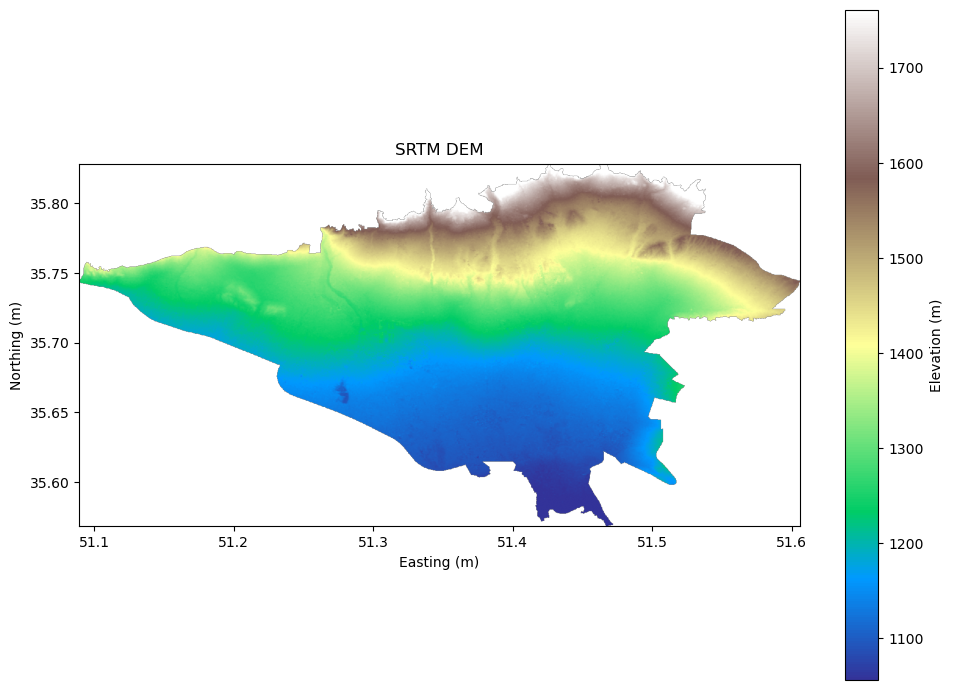

In [37]:
with rasterio.open(FINAL_PATH) as src:
    dem = src.read(1, masked=True)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Bounds:", src.bounds)
    print("Minimum:", float(dem.min()))
    print("Maximum:", float(dem.max()))
    print("Mean:", float(dem.mean()))
plot_raster(FINAL_PATH, "SRTM DEM", "Elevation (m)", "terrain", pct=(1,99))

## 10. Reproject the DEM to a Local 30 m UTM Grid

Terrain and hydrology calculations require metric distances. The notebook automatically selects the UTM zone from the AOI center and reprojects the clipped SRTM DEM to a **30 m** grid using bilinear resampling.

Analysis CRS: EPSG:32639
Projected DEM: outputs/dem_products/dem_30m_utm.tif


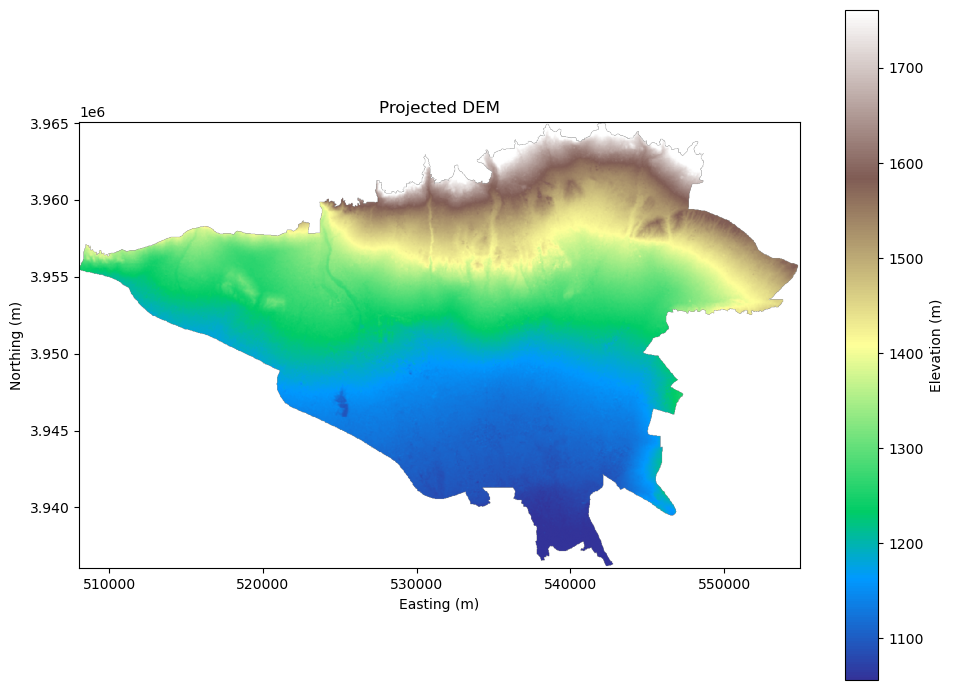

In [38]:
PROJECTED_DEM_PATH = PRODUCTS_DIR / "dem_30m_utm.tif"
with rasterio.open(FINAL_PATH) as src:
    w, s, e, n = transform_bounds(src.crs, "EPSG:4326", *src.bounds)
    lon, lat = (w + e) / 2, (s + n) / 2
    zone = int((lon + 180) // 6) + 1
    target_crs = rasterio.crs.CRS.from_epsg((32600 if lat >= 0 else 32700) + zone)
    transform, width, height = calculate_default_transform(src.crs, target_crs, src.width, src.height,
                                                           *src.bounds, resolution=TARGET_RESOLUTION)
    profile = src.profile.copy()
    profile.pop("blockxsize", None)
    profile.pop("blockysize", None)
    profile.update(crs=target_crs, transform=transform, width=width, height=height, nodata=NODATA,
                   compress="DEFLATE", tiled=True, blockxsize=BLOCK_SIZE, blockysize=BLOCK_SIZE,
                   BIGTIFF="IF_SAFER")
    with rasterio.open(PROJECTED_DEM_PATH, "w", **profile) as dst:
        reproject(source=rasterio.band(src, 1), destination=rasterio.band(dst, 1),
                  src_transform=src.transform, src_crs=src.crs, src_nodata=src.nodata,
                  dst_transform=transform, dst_crs=target_crs, dst_nodata=NODATA,
                  resampling=Resampling.bilinear)
print("Analysis CRS:", target_crs)
print("Projected DEM:", PROJECTED_DEM_PATH.resolve())
plot_raster(PROJECTED_DEM_PATH, "Projected DEM", "Elevation (m)", "terrain", pct=(1,99))

## 11. Load the Metric DEM and Compute Base Derivatives

The projected DEM is loaded as a floating-point array with an explicit validity mask. Cell dimensions and cell area are calculated from the raster transform, followed by first-order elevation gradients used for slope and aspect.

In [12]:
with rasterio.open(PROJECTED_DEM_PATH) as src:
    z = src.read(1).astype("float64")
    valid = src.read_masks(1) > 0
    z[~valid] = np.nan
    dx, dy = abs(src.transform.a), abs(src.transform.e)
    cell_area = dx * dy
gy, gx = np.gradient(z, dy, dx)
slope_rad = np.arctan(np.hypot(gx, gy))
slope_deg = np.degrees(slope_rad)
slope_pct = np.tan(slope_rad) * 100
aspect = np.mod(np.degrees(np.arctan2(-gx, gy)), 360)
aspect[np.hypot(gx, gy) == 0] = np.nan

## 12. Filled DEM

Pits and depressions are filled with `pysheds` to create a drainage-compatible elevation surface. This intermediate raster removes closed depressions that would otherwise interrupt downstream flow routing.

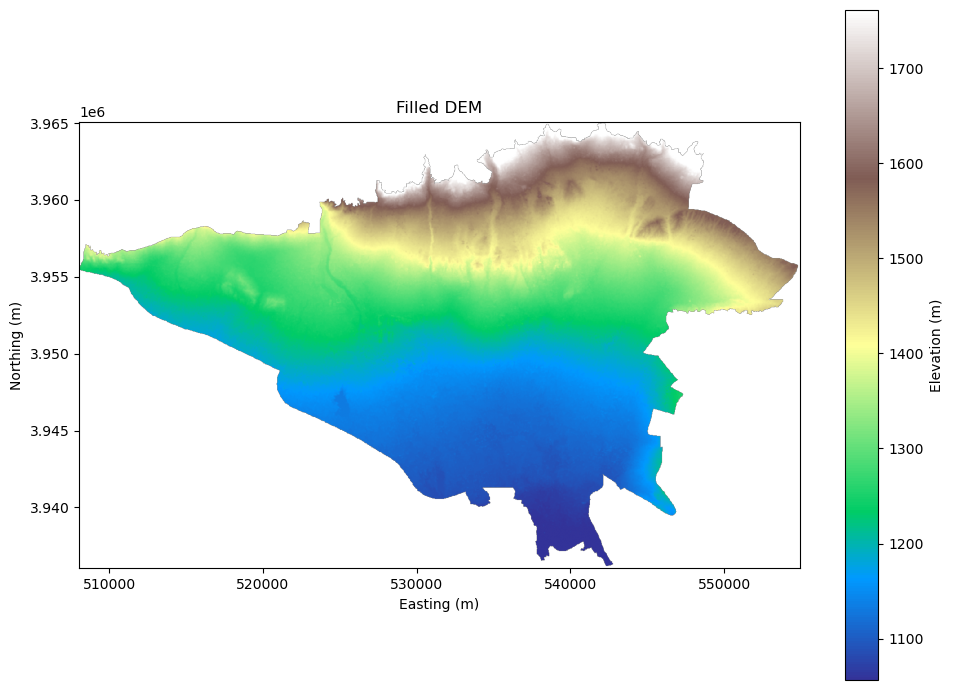

In [39]:
grid = Grid.from_raster(str(PROJECTED_DEM_PATH))
dem_h = grid.read_raster(str(PROJECTED_DEM_PATH))
pit_filled = grid.fill_pits(dem_h)
filled = grid.fill_depressions(pit_filled)
conditioned = grid.resolve_flats(filled)
filled_arr = np.asarray(filled, dtype="float64")
conditioned_arr = np.asarray(conditioned, dtype="float64")
filled_arr[~valid] = np.nan
conditioned_arr[~valid] = np.nan
FILLED_PATH = PRODUCTS_DIR / "filled_dem.tif"
save_array(FILLED_PATH, filled_arr, PROJECTED_DEM_PATH)
plot_raster(FILLED_PATH, "Filled DEM", "Elevation (m)", "terrain", pct=(1,99))

## 13. Hydrologically Conditioned DEM

Flat areas in the filled DEM are resolved to produce a hydrologically conditioned surface suitable for deterministic D8 flow-direction calculations.

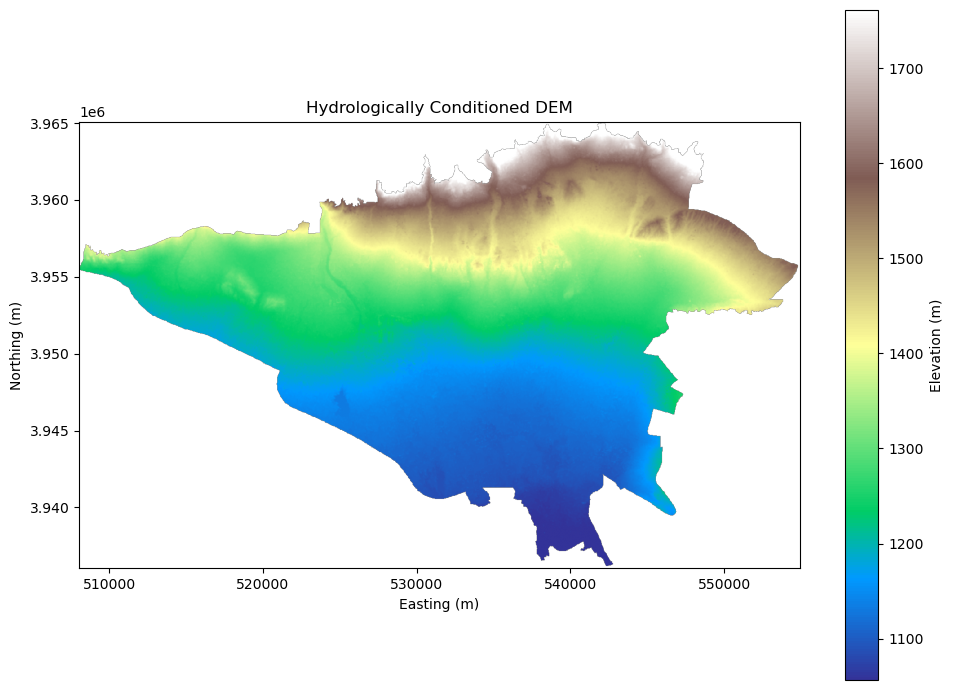

In [40]:
CONDITIONED_PATH = PRODUCTS_DIR / "conditioned_dem.tif"
save_array(CONDITIONED_PATH, conditioned_arr, PROJECTED_DEM_PATH)
plot_raster(CONDITIONED_PATH, "Hydrologically Conditioned DEM", "Elevation (m)", "terrain", pct=(1,99))

## 14. Sink Depth

Sink depth is calculated as the positive elevation difference between the depression-filled DEM and the original projected DEM. Larger values indicate deeper depressions that required filling during hydrologic conditioning.

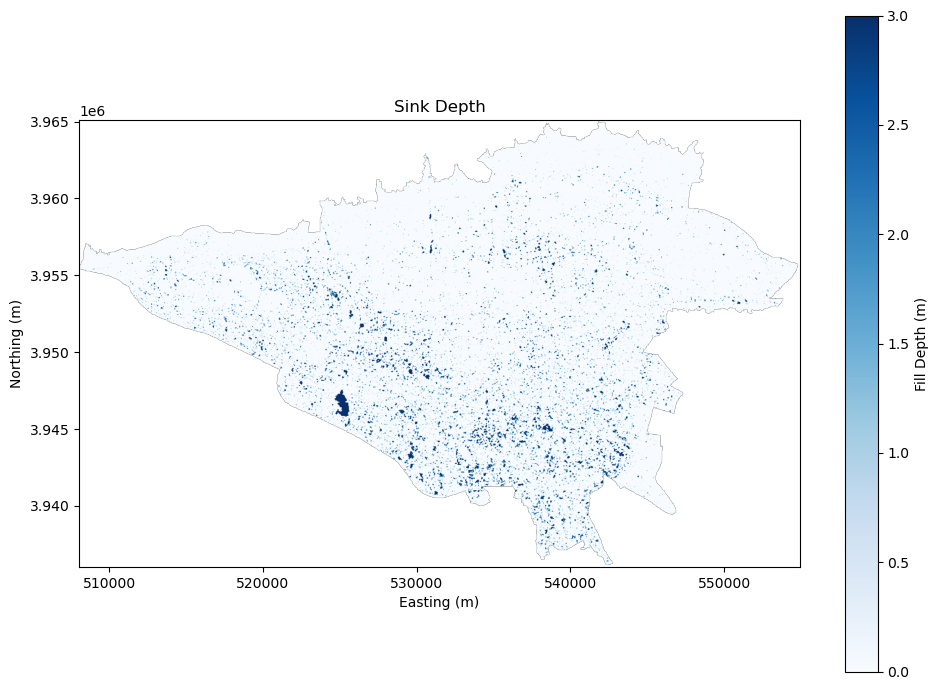

In [41]:
sink_depth = np.where(valid, np.maximum(filled_arr - z, 0), np.nan)
SINK_DEPTH_PATH = PRODUCTS_DIR / "sink_depth.tif"
save_array(SINK_DEPTH_PATH, sink_depth, PROJECTED_DEM_PATH)
plot_raster(SINK_DEPTH_PATH, "Sink Depth", "Fill Depth (m)", "Blues", pct=(0,99), vmin=0)

## 15. Sink Mask

The sink mask is a binary raster identifying cells where the filled surface is higher than the original DEM. Valid terrain cells are classified as **No Sink** or **Sink**.

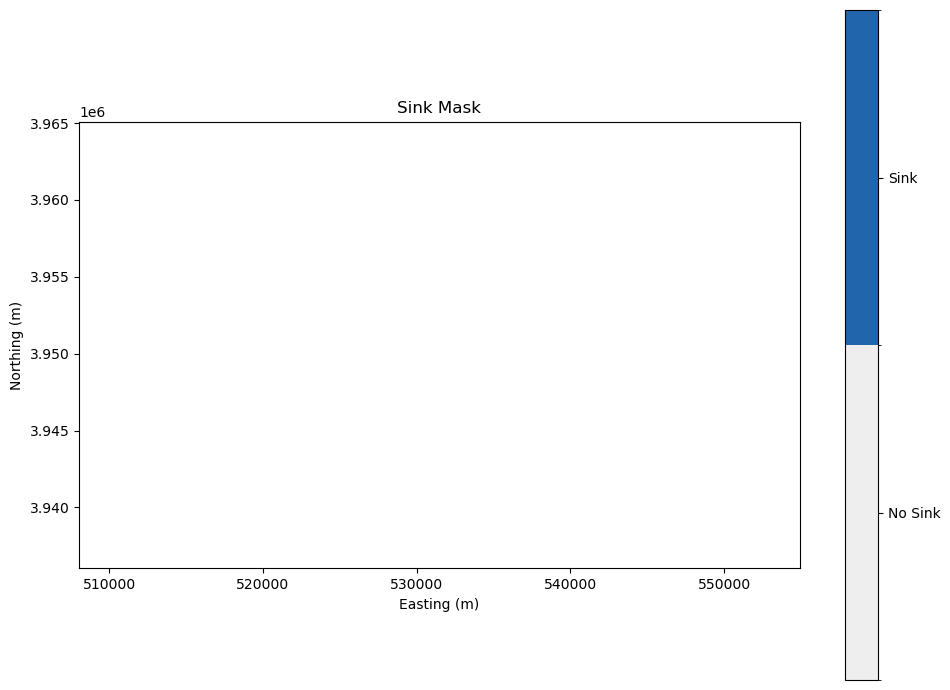

In [42]:
sink_mask = np.where(valid, (sink_depth > 1e-6).astype("uint8"), 255)
SINK_MASK_PATH = PRODUCTS_DIR / "sink_mask.tif"
save_array(SINK_MASK_PATH, sink_mask, PROJECTED_DEM_PATH, "uint8", 255)
plot_raster(
    SINK_MASK_PATH, "Sink Mask", mode="categorical",
    codes=[0,1], labels=["No Sink","Sink"],
    colors=["#eeeeee","#2166ac"]
)

## 16. Slope in Degrees

Slope is derived from the x- and y-direction elevation gradients and expressed in degrees. Steeper terrain has larger slope values.

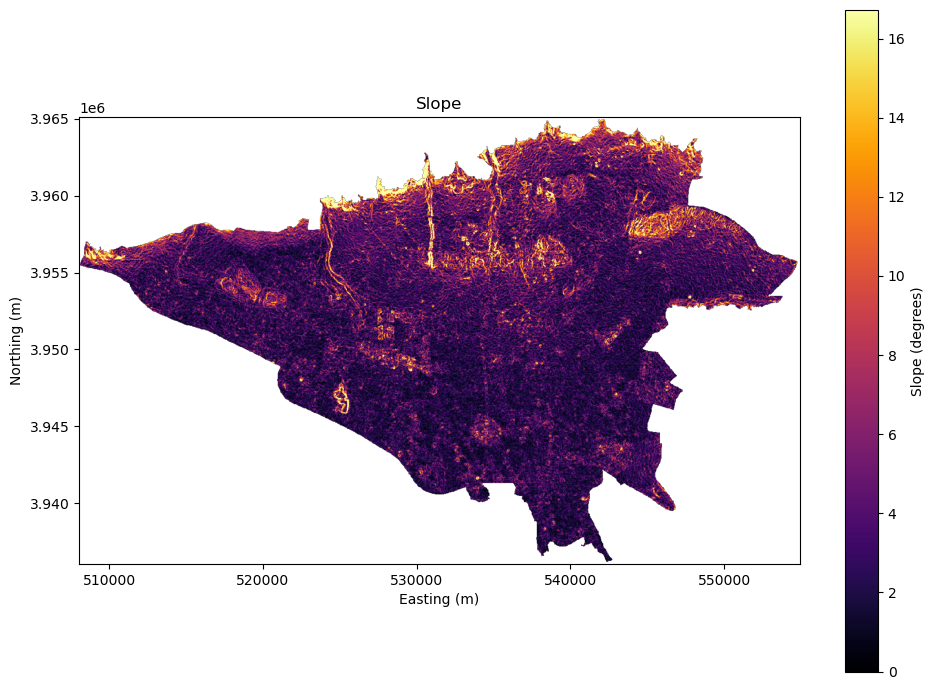

In [43]:
SLOPE_PATH = PRODUCTS_DIR / "slope_degrees.tif"
save_array(SLOPE_PATH, np.where(valid, slope_deg, np.nan), PROJECTED_DEM_PATH)
plot_raster(SLOPE_PATH, "Slope", "Slope (degrees)", "inferno", pct=(0,99), vmin=0)

## 17. Slope in Percent

The same gradient-derived slope is converted to percent rise using `tan(slope) × 100`, providing an alternative representation commonly used in engineering and terrain analysis.

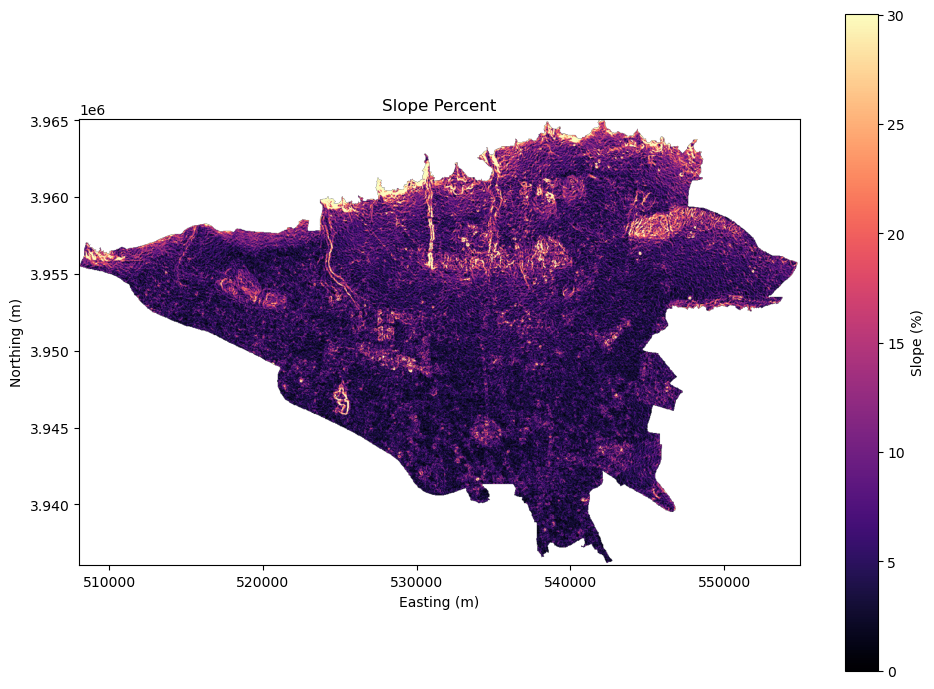

In [44]:
SLOPE_PERCENT_PATH = PRODUCTS_DIR / "slope_percent.tif"
save_array(SLOPE_PERCENT_PATH, np.where(valid, slope_pct, np.nan), PROJECTED_DEM_PATH)
plot_raster(SLOPE_PERCENT_PATH, "Slope Percent", "Slope (%)", "magma", pct=(0,99), vmin=0)

## 18. Aspect

Aspect represents the downslope-facing direction from **0° to 360°**. Flat cells are assigned no aspect and remain masked in the visualization.

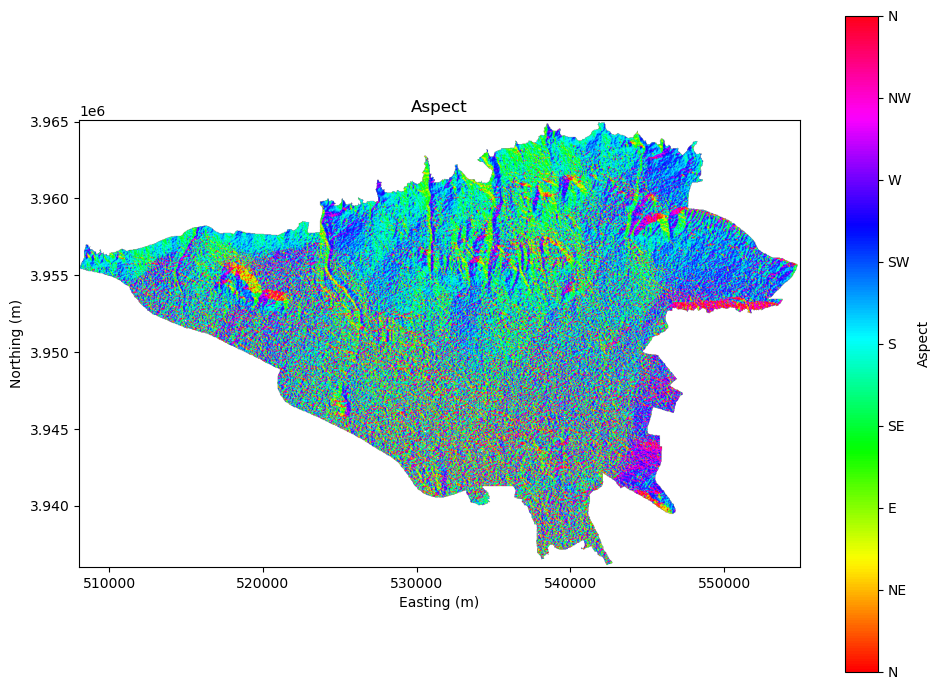

In [46]:
ASPECT_PATH = PRODUCTS_DIR / "aspect.tif"
save_array(ASPECT_PATH, np.where(valid, aspect, np.nan), PROJECTED_DEM_PATH)
with rasterio.open(ASPECT_PATH) as src:
    s = max(src.width/MAX_PREVIEW, src.height/MAX_PREVIEW, 1)
    data = src.read(1, out_shape=(max(1,int(src.height/s)), max(1,int(src.width/s))), masked=True)
    extent = plotting_extent(src)

plt.figure(figsize=(10,7))
im = plt.imshow(data, extent=extent, cmap="hsv", vmin=0, vmax=360)
cb = plt.colorbar(im, ticks=[0,45,90,135,180,225,270,315,360])
cb.ax.set_yticklabels(["N","NE","E","SE","S","SW","W","NW","N"])
cb.set_label("Aspect")
plt.title("Aspect")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.tight_layout()
plt.show()

## 19. Hillshade

A shaded-relief raster is generated from slope and aspect using a simulated illumination altitude of **45°** and azimuth of **315°**. The result emphasizes landform shape and local relief.

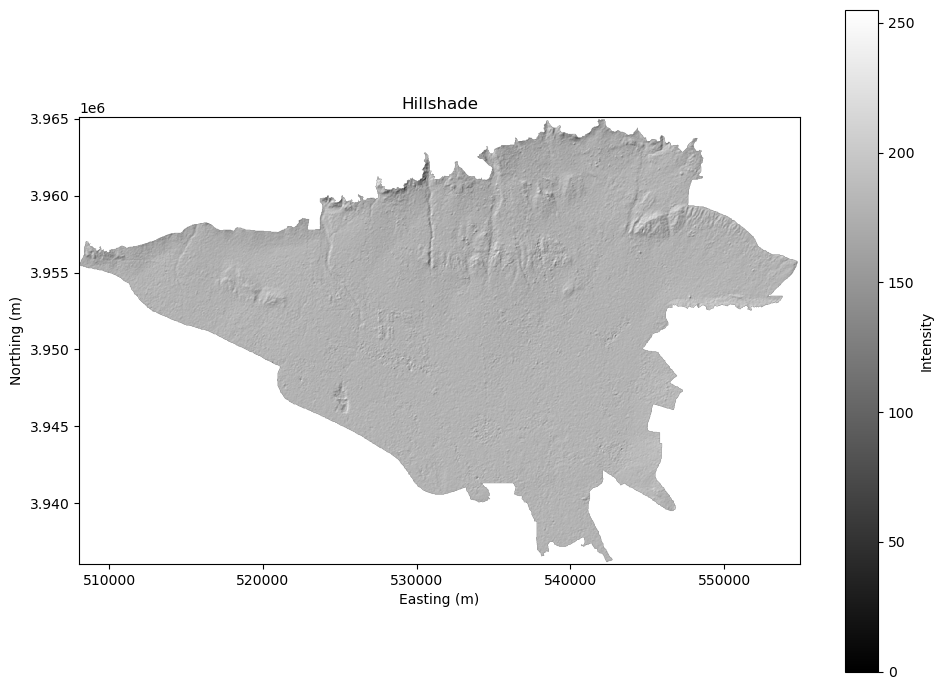

In [47]:
alt = np.radians(45)
az = np.radians(315)
aspect_hs = np.nan_to_num(aspect, nan=0.0)
hillshade = 255 * np.clip(np.sin(alt) * np.cos(slope_rad) + np.cos(alt) * np.sin(slope_rad) *
                          np.cos(az - np.radians(aspect_hs)), 0, 1)
hillshade[~valid] = np.nan
HILLSHADE_PATH = PRODUCTS_DIR / "hillshade.tif"
save_array(HILLSHADE_PATH, hillshade, PROJECTED_DEM_PATH)
plot_raster(HILLSHADE_PATH, "Hillshade", "Intensity", "gray", vmin=0, vmax=255)

## 20. Laplacian Curvature

Laplacian curvature is estimated from the divergence of the elevation gradient. A zero-centered diverging color scale highlights positive and negative curvature patterns while limiting the visual influence of extreme values.

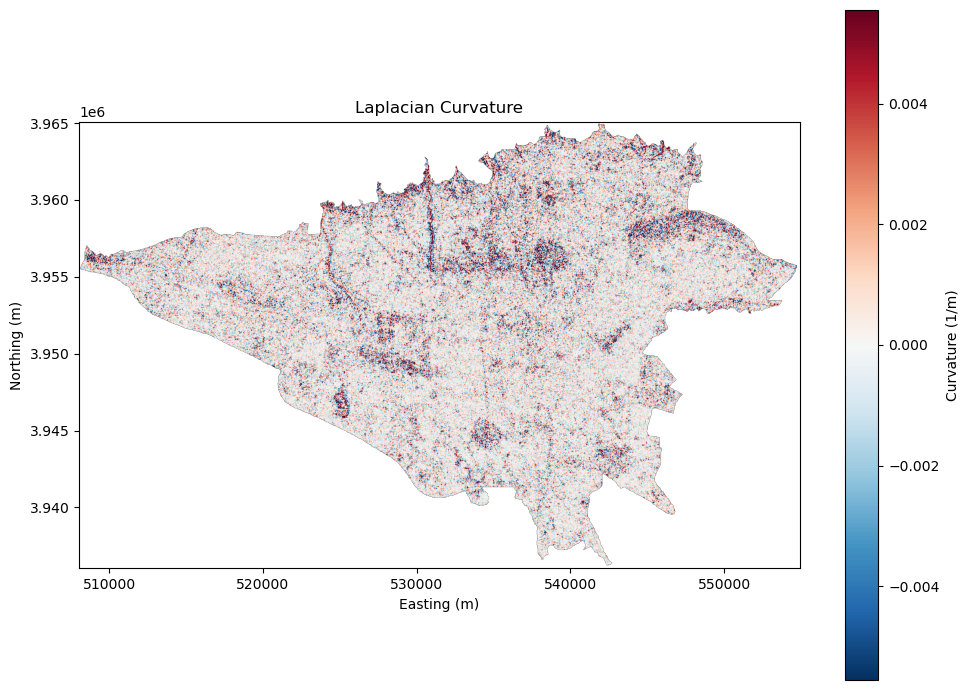

In [48]:
curvature = np.gradient(gx, dx, axis=1) + np.gradient(gy, dy, axis=0)
curvature[~valid] = np.nan
CURVATURE_PATH = PRODUCTS_DIR / "laplacian_curvature.tif"
save_array(CURVATURE_PATH, curvature, PROJECTED_DEM_PATH)
plot_raster(CURVATURE_PATH, "Laplacian Curvature", "Curvature (1/m)",
            "RdBu_r", mode="diverging", pct=98)

## 21. Topographic Position Index (TPI)

TPI is calculated as the difference between each cell elevation and the local mean elevation within the configured moving window. Positive values tend to indicate locally elevated positions; negative values indicate locally lower positions.

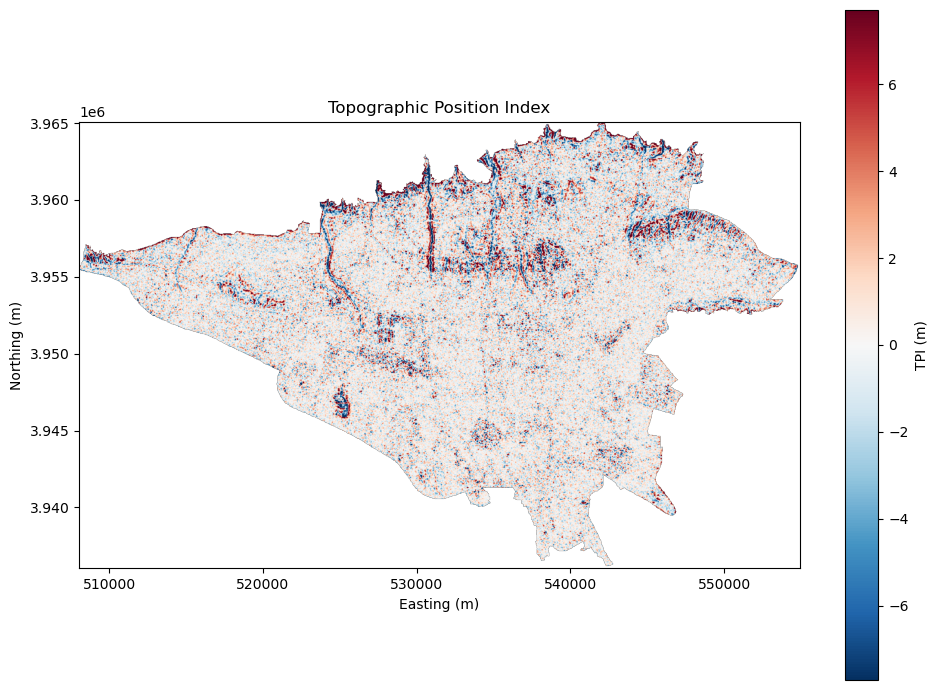

In [49]:
z0 = np.where(valid, z, 0)
w = uniform_filter(valid.astype("float64"), size=TPI_WINDOW, mode="constant", cval=0)
m = uniform_filter(z0, size=TPI_WINDOW, mode="constant", cval=0)
local_mean = np.divide(m, w, out=np.full_like(z, np.nan), where=w > 0)
tpi = np.where(valid, z - local_mean, np.nan)
TPI_PATH = PRODUCTS_DIR / "tpi.tif"
save_array(TPI_PATH, tpi, PROJECTED_DEM_PATH)
plot_raster(TPI_PATH, "Topographic Position Index", "TPI (m)",
            "RdBu_r", mode="diverging", pct=98)

## 22. Terrain Ruggedness Index (TRI)

TRI summarizes local elevation differences between each cell and its eight neighboring cells. Larger values indicate more rugged terrain.

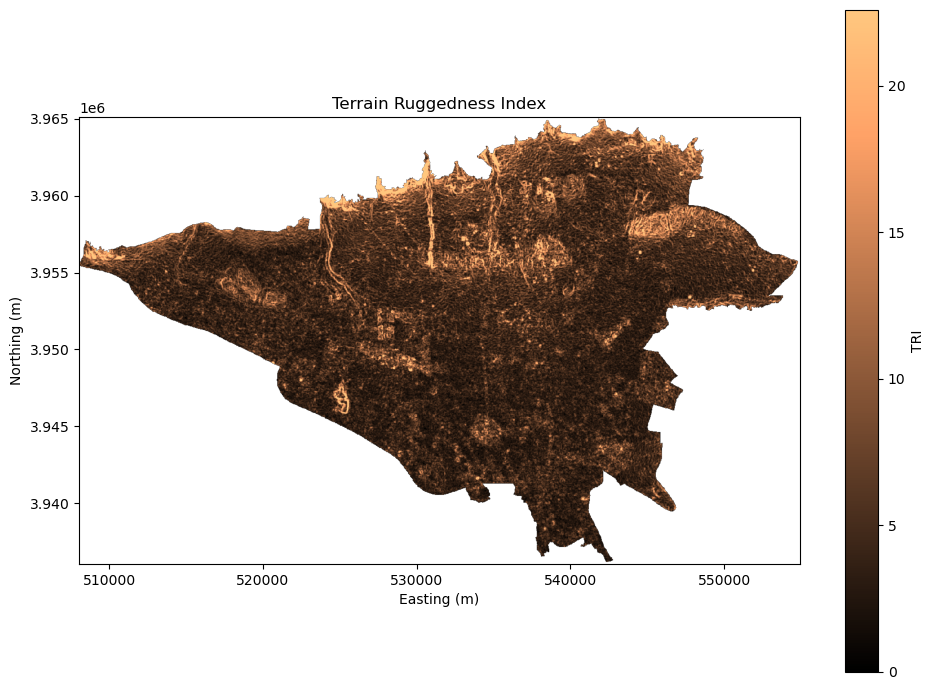

In [50]:
k = np.ones((3, 3), dtype="float64")
k[1, 1] = 0
n = convolve(valid.astype("float64"), k, mode="constant", cval=0)
s1 = convolve(z0, k, mode="constant", cval=0)
s2 = convolve(z0 * z0, k, mode="constant", cval=0)
tri = np.sqrt(np.maximum(s2 - 2 * z * s1 + n * z * z, 0))
tri[~valid] = np.nan
TRI_PATH = PRODUCTS_DIR / "tri.tif"
save_array(TRI_PATH, tri, PROJECTED_DEM_PATH)
plot_raster(TRI_PATH, "Terrain Ruggedness Index", "TRI",
            "copper", pct=(0,99), vmin=0)

## 23. Roughness

Terrain roughness is computed as the elevation range (`local maximum − local minimum`) within a 3 × 3 neighborhood. It provides a simple measure of short-range surface variability.

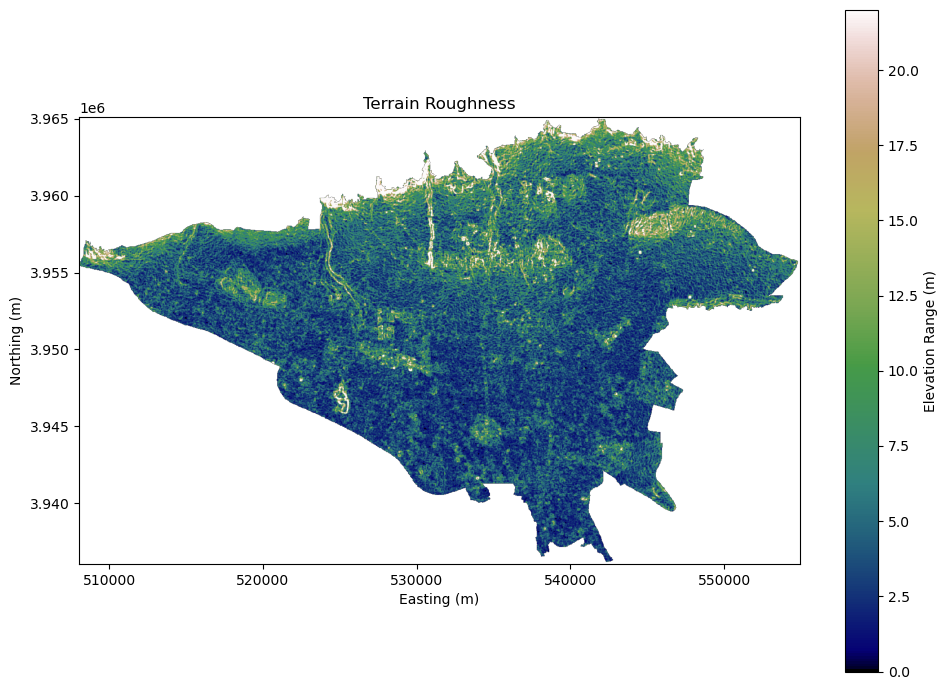

In [51]:
zmax = maximum_filter(np.where(valid, z, -np.inf), size=3, mode="constant", cval=-np.inf)
zmin = minimum_filter(np.where(valid, z, np.inf), size=3, mode="constant", cval=np.inf)
roughness = zmax - zmin
roughness[~valid] = np.nan
ROUGHNESS_PATH = PRODUCTS_DIR / "roughness.tif"
save_array(ROUGHNESS_PATH, roughness, PROJECTED_DEM_PATH)
plot_raster(ROUGHNESS_PATH, "Terrain Roughness", "Elevation Range (m)",
            "gist_earth", pct=(0,99), vmin=0)

## 24. D8 Flow Direction

Flow direction is calculated from the hydrologically conditioned DEM using the D8 method. Each cell drains to one of its eight neighboring cells.

| Direction | Code | Direction | Code |
|---|---:|---|---:|
| E | 1 | W | 16 |
| SE | 2 | NW | 32 |
| S | 4 | N | 64 |
| SW | 8 | NE | 128 |

Cells outside the valid DEM are written as `0` in the output flow-direction raster.

D8 flow-direction raster generated successfully.


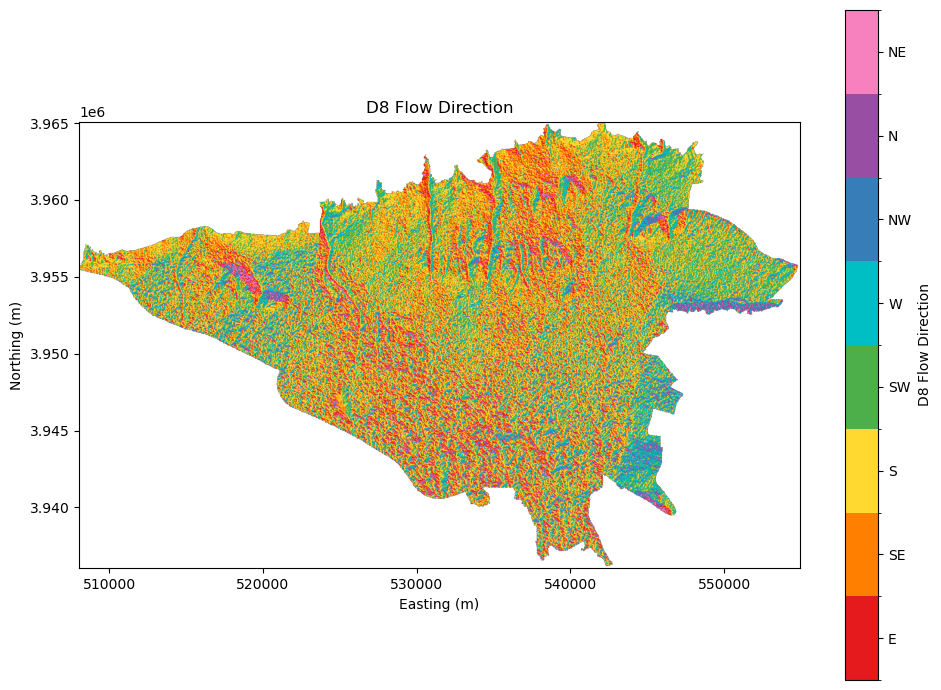

In [53]:
D8 = (64,128,1,2,4,8,16,32)
fdir = grid.flowdir(conditioned, dirmap=D8)
fd = np.asarray(fdir, dtype=np.int16)
fd[~valid] = 0

FLOWDIR_PATH = PRODUCTS_DIR / "flow_direction_d8.tif"

with rasterio.open(PROJECTED_DEM_PATH) as src:
    profile = src.profile.copy()

profile.pop("blockxsize", None)
profile.pop("blockysize", None)
profile.update(dtype="uint8", nodata=0, compress="DEFLATE", tiled=True,
               blockxsize=256, blockysize=256)

with rasterio.open(FLOWDIR_PATH, "w", **profile) as dst:
    dst.write(fd.astype("uint8"), 1)

with rasterio.open(FLOWDIR_PATH) as src:
    s = max(src.width/MAX_PREVIEW, src.height/MAX_PREVIEW, 1)
    data = src.read(1, out_shape=(max(1,int(src.height/s)),max(1,int(src.width/s))))
    extent = plotting_extent(src)

codes = [1,2,4,8,16,32,64,128]
labels = ["E","SE","S","SW","W","NW","N","NE"]
colors = ["#e41a1c","#ff7f00","#ffd92f","#4daf4a","#00bfc4","#377eb8","#984ea3","#f781bf"]

display = np.full(data.shape, np.nan)

for i, code in enumerate(codes):
    display[data == code] = i

display = np.ma.masked_invalid(display)

cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5,8.5),8)

plt.figure(figsize=(10,7))
im = plt.imshow(display, extent=extent, cmap=cmap, norm=norm)
cb = plt.colorbar(im, ticks=np.arange(8))
cb.ax.set_yticklabels(labels)
cb.set_label("D8 Flow Direction")
plt.title("D8 Flow Direction")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.tight_layout()
plt.show()

print("D8 values:", np.unique(fd[valid], return_counts=True))

## 25. D8 Flow Accumulation

Flow accumulation counts the number of upstream cells contributing to each location. The preview uses a `log1p` transform so both low- and high-contributing areas remain visible.

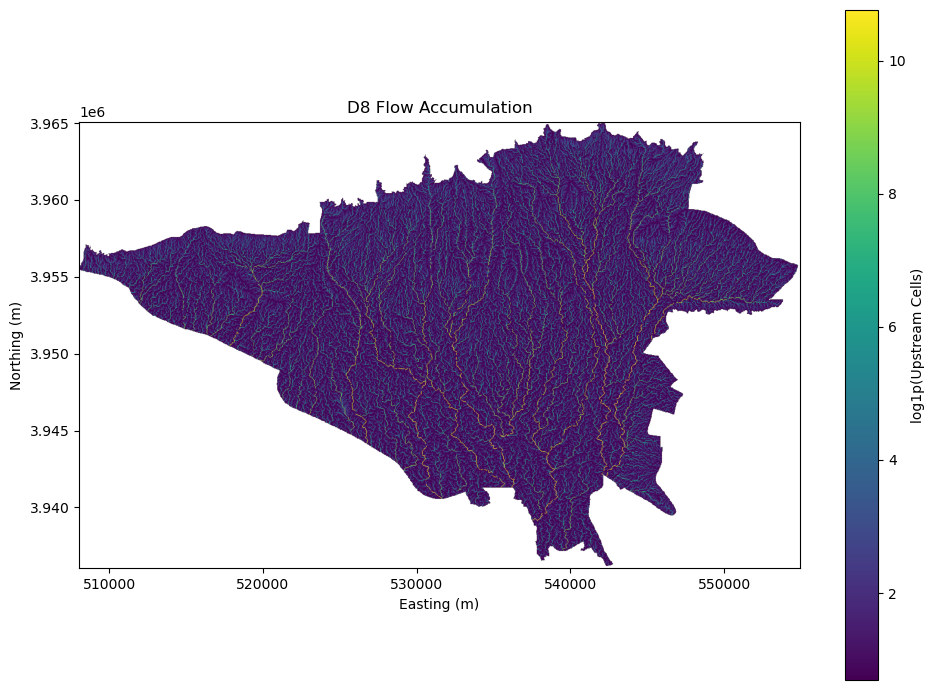

In [54]:

acc = grid.accumulation(fdir, dirmap=D8)
acc_arr = np.asarray(acc, dtype="float64")
acc_arr[~valid] = np.nan
ACC_PATH = PRODUCTS_DIR / "flow_accumulation_cells.tif"
save_array(ACC_PATH, acc_arr, PROJECTED_DEM_PATH)
plot_raster(
    ACC_PATH, "D8 Flow Accumulation", "log1p(Upstream Cells)",
    "viridis", log=True, pct=(0,99.8)
)

## 26. Drainage Area

Flow accumulation is converted from cell counts to contributing area in square kilometers using the projected raster cell area. This produces a physically interpretable drainage-area surface.

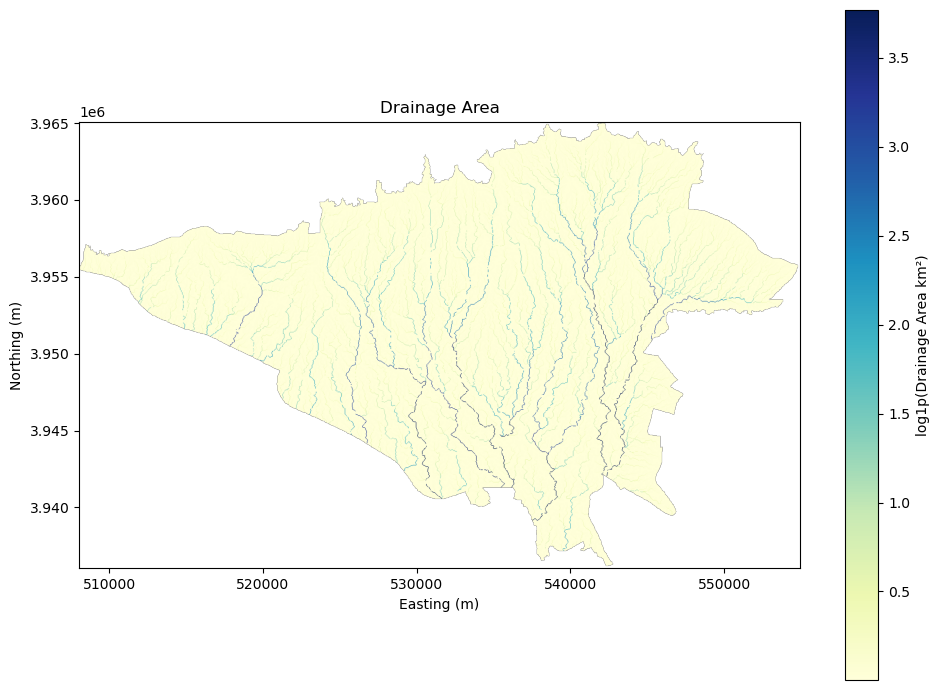

In [55]:
drainage_area = (acc_arr + 1) * cell_area / 1e6
drainage_area[~valid] = np.nan
DRAINAGE_AREA_PATH = PRODUCTS_DIR / "drainage_area_km2.tif"
save_array(DRAINAGE_AREA_PATH, drainage_area, PROJECTED_DEM_PATH)
plot_raster(
    DRAINAGE_AREA_PATH, "Drainage Area", "log1p(Drainage Area km²)",
    "YlGnBu", log=True, pct=(0,99.8)
)

## 27. Topographic Wetness Index (TWI)

TWI combines an approximation of specific catchment area with local slope:

**TWI = ln(a / tan(β))**

where `a` is the specific contributing area approximation and `β` is the local slope angle. Small numerical floors are used to avoid division by zero or undefined logarithms.


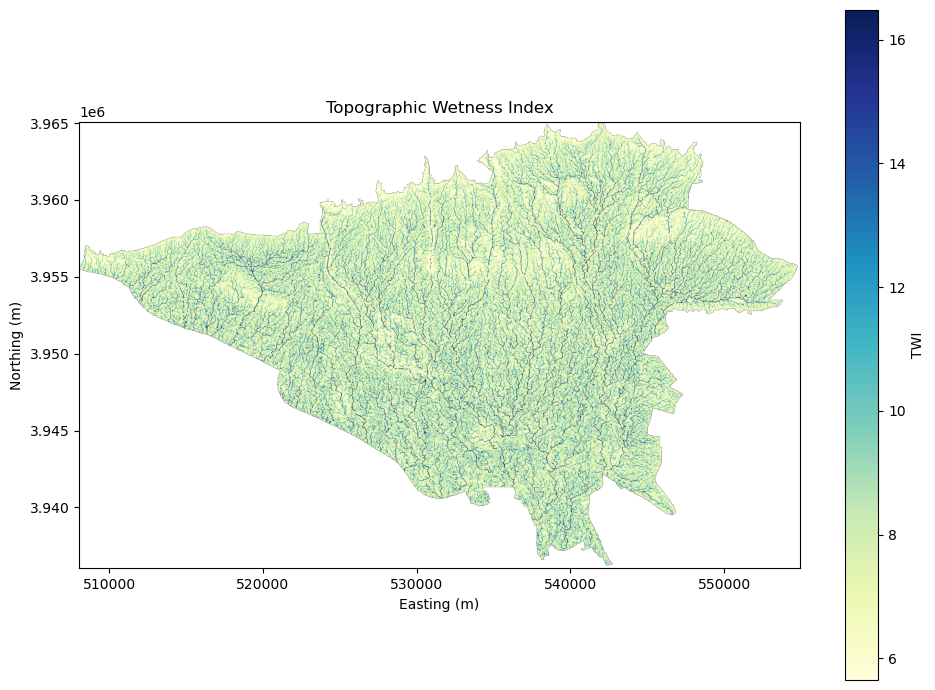

In [56]:
specific_area = (acc_arr + 1) * np.sqrt(cell_area)
twi = np.log(np.maximum(specific_area, 1e-6) / np.maximum(np.tan(slope_rad), 1e-4))
twi[~valid] = np.nan
TWI_PATH = PRODUCTS_DIR / "twi.tif"
save_array(TWI_PATH, twi, PROJECTED_DEM_PATH)
plot_raster(TWI_PATH, "Topographic Wetness Index", "TWI",
            "YlGnBu", pct=(1,99))

## 28. Stream Raster

Cells with a contributing drainage area greater than or equal to `STREAM_THRESHOLD_KM2` are classified as stream cells. The threshold is converted to an equivalent number of raster cells from the 30 m grid area.

Stream threshold: 2.0 km² = 2223 cells
Max accumulation: 112123 cells


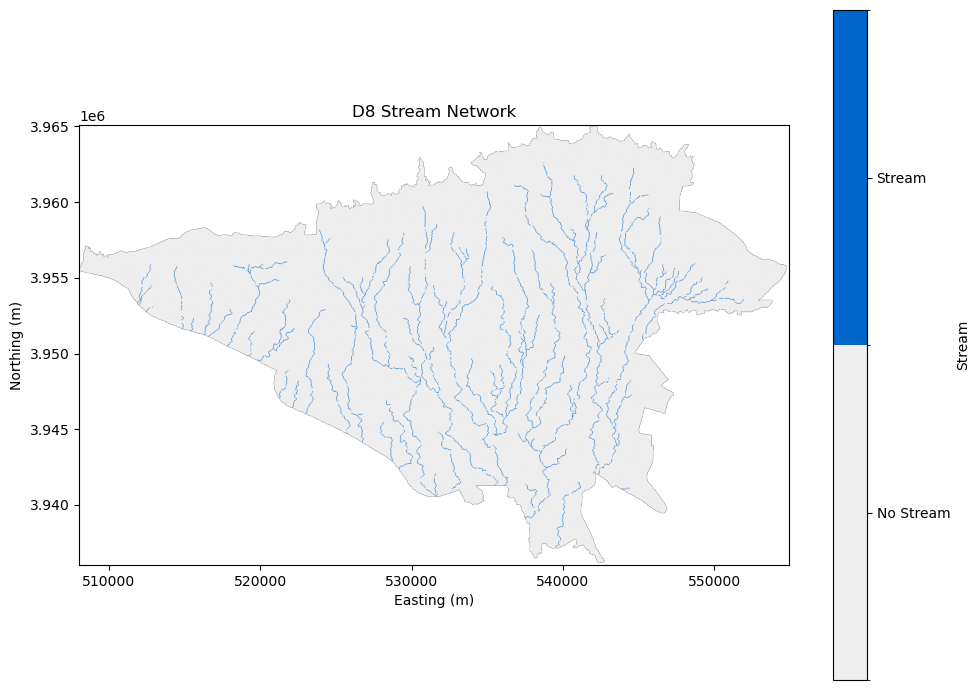

In [59]:
threshold_cells = max(1, int(np.ceil(STREAM_THRESHOLD_KM2 * 1e6 / cell_area)))

stream_arr = (acc_arr >= threshold_cells).astype("uint8")
stream_arr[~valid] = 255

STREAM_RASTER_PATH = PRODUCTS_DIR / "streams_d8.tif"

with rasterio.open(PROJECTED_DEM_PATH) as src:
    profile = src.profile.copy()

profile.pop("blockxsize", None)
profile.pop("blockysize", None)
profile.update(dtype="uint8", nodata=255, compress="DEFLATE", tiled=True,
               blockxsize=256, blockysize=256)

with rasterio.open(STREAM_RASTER_PATH, "w", **profile) as dst:
    dst.write(stream_arr, 1)

print("Stream threshold:", STREAM_THRESHOLD_KM2, "km² =", threshold_cells, "cells")
print("Max accumulation:", np.nanmax(acc_arr))
print("Unique stream values:", np.unique(stream_arr, return_counts=True))

with rasterio.open(STREAM_RASTER_PATH) as src:
    s = max(src.width / MAX_PREVIEW, src.height / MAX_PREVIEW, 1)
    data = src.read(1, out_shape=(max(1, int(src.height / s)), max(1, int(src.width / s))), masked=False)
    data = np.ma.masked_where(data == 255, data)
    extent = plotting_extent(src)

cmap = ListedColormap(["#eeeeee", "#0066cc"])
norm = BoundaryNorm([-0.5, 0.5, 1.5], 2)

plt.figure(figsize=(10, 7))
im = plt.imshow(data, extent=extent, cmap=cmap, norm=norm)
cb = plt.colorbar(im, ticks=[0, 1])
cb.ax.set_yticklabels(["No Stream", "Stream"])
cb.set_label("Stream")
plt.title("D8 Stream Network")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.tight_layout()
plt.show()

## 29. Vector Stream Network

The D8 stream raster is converted into a vector river network with `pysheds`. Stream segments are saved as ESRI Shapefiles in both the local UTM CRS and **EPSG:4326 (WGS84)**. Segment length in meters is added to the projected stream layer.

Stream segments: 164
UTM Shapefile: outputs/dem_products/streams_d8.shp
WGS84 Shapefile: outputs/dem_products/streams_d8_wgs84.shp


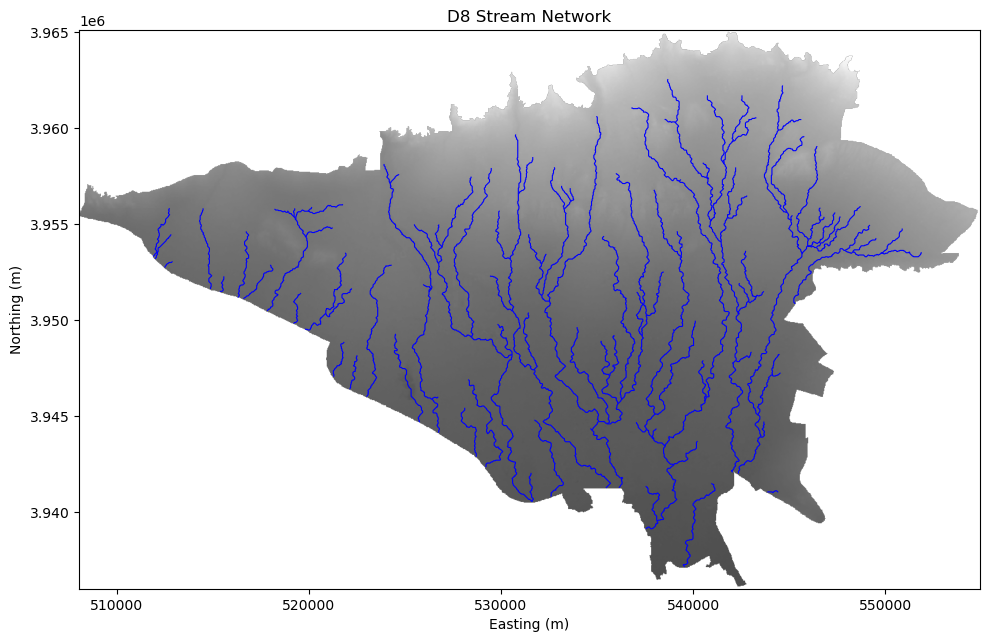

In [58]:
network = grid.extract_river_network(fdir, stream_condition, dirmap=D8)
streams = gpd.GeoDataFrame.from_features(network["features"], crs=target_crs)
if streams.empty:
    raise RuntimeError("No streams were extracted. Lower STREAM_THRESHOLD_KM2.")
streams["length_m"] = streams.length
STREAMS_SHP = PRODUCTS_DIR / "streams_d8.shp"
STREAMS_WGS84_SHP = PRODUCTS_DIR / "streams_d8_wgs84.shp"
for stem in (STREAMS_SHP.stem, STREAMS_WGS84_SHP.stem):
    for p in PRODUCTS_DIR.glob(f"{stem}.*"):
        p.unlink()
streams.to_file(STREAMS_SHP, driver="ESRI Shapefile")
streams.to_crs("EPSG:4326").to_file(STREAMS_WGS84_SHP, driver="ESRI Shapefile")
print("Segments:", len(streams))
print("UTM Shapefile:", STREAMS_SHP.resolve())
print("WGS84 Shapefile:", STREAMS_WGS84_SHP.resolve())
with rasterio.open(PROJECTED_DEM_PATH) as src:
    s = max(src.width/MAX_PREVIEW, src.height/MAX_PREVIEW, 1)
    dem = src.read(1, out_shape=(max(1,int(src.height/s)), max(1,int(src.width/s))), masked=True)
    extent = plotting_extent(src)

plt.figure(figsize=(10,7))
plt.imshow(dem, extent=extent, cmap="gray", alpha=.7)
streams.plot(ax=plt.gca(), color="blue", linewidth=.8)
plt.title("D8 Stream Network")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.tight_layout()
plt.show()

## 30. Stream Network Visualization

The extracted stream network is overlaid on the projected DEM to provide a final visual check of drainage structure and stream alignment with the terrain.

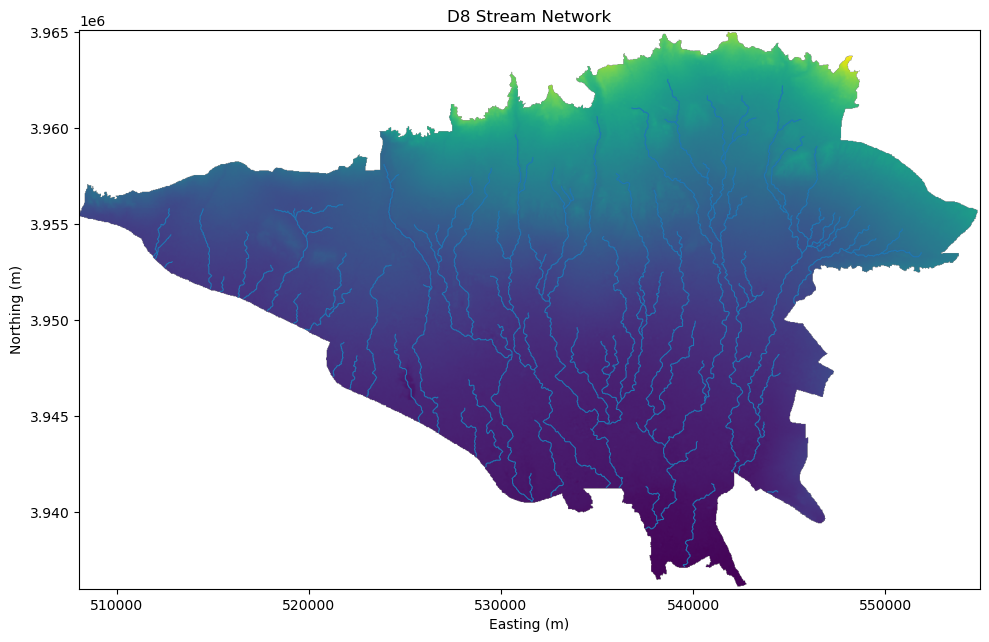

In [34]:
with rasterio.open(PROJECTED_DEM_PATH) as src:
    scale = max(src.width / MAX_PREVIEW, src.height / MAX_PREVIEW, 1)
    h, w = max(1, int(src.height / scale)), max(1, int(src.width / scale))
    base = src.read(1, out_shape=(h, w), masked=True)
    extent = plotting_extent(src)
plt.figure(figsize=(10, 7))
plt.imshow(base, extent=extent)
ax = plt.gca()
streams.plot(ax=ax, linewidth=0.8)
plt.title("D8 Stream Network")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.tight_layout()
plt.show()

## 31. Output Inventory and Cleanup

Temporary mosaic files and cached HGT tiles can be removed according to `KEEP_MOSAIC` and `KEEP_HGT`. The notebook then prints the contents of `dem_products/` so the final raster and vector deliverables can be reviewed.

### Expected product files

Core outputs include `dem_30m_utm.tif`, `conditioned_dem.tif`, slope/aspect/hillshade rasters, terrain indices, D8 flow products, drainage area, TWI, `streams_d8.tif`, and stream Shapefile components.

In [35]:
if not KEEP_MOSAIC:
    MOSAIC_PATH.unlink(missing_ok=True)
if not KEEP_HGT:
    for p in HGT_FILES:
        Path(p).unlink(missing_ok=True)
for p in sorted(PRODUCTS_DIR.iterdir()):
    print(p)

Generated products are available in outputs/dem_products/.
